<a href="https://colab.research.google.com/github/RafaelCaballero/BME/blob/main/modelos_texto_huggingface.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table>
<tr>
<td><img src="https://www.institutobme.es/dam/layout/bme-logo.svg" width="150"></td>
<td><table><tr><td><h1>Modelos IA para texto</h1></td></tr>
           <tr><td><h3>Rafael Caballero Roldán</h3></td></tr></table></td>

</tr>
</table>

Este cuaderno presenta varias capacidades de modelos de lenguaje que pueden descargarse desde [Hugging Face](https://huggingface.co/) y ejecutarse localmente:

1. análisis de sentimiento;
2. clasificación de textos sin entrenamiento adicional (*zero-shot*);
3. resumen automático;
4. representación de textos mediante *embeddings* y cálculo de similitud semántica.

La primera ejecución descarga los modelos (esto puede tardar). Después quedan guardados en la caché local de Hugging Face y pueden reutilizarse sin volver a descargarlos, si estamos en local. En google colab habrá que instalarlos cada vez-


## 1. Instalación

Este cuaderno utiliza una versión 4.x de `transformers`, porque mantiene una API estable para las tareas mostradas.

En un entorno Conda también puede instalarse PyTorch previamente con:

```bash
conda install -c pytorch pytorch
```


In [1]:
%pip uninstall -y gradio gradio_client

In [2]:
%pip install "transformers>=4.46,<5" sentencepiece sentence-transformers torch pandas matplotlib scikit-learn accelerate

Tras la instalaci´no es conveniente dar Entorno de Ejecución + Reiniciar Sesión, para que se cargue todo correctamente

## 2. Comprobar el dispositivo disponible

Si existe una GPU CUDA, las tuberías la utilizarán. En caso contrario funcionarán con CPU, aunque el resumen puede tardar más.


In [3]:
import torch

DEVICE = 0 if torch.cuda.is_available() else -1
print("Dispositivo:", "GPU CUDA" if DEVICE == 0 else "CPU")
print("Versión de PyTorch:", torch.__version__)

Dispositivo: CPU
Versión de PyTorch: 2.11.0+cpu


## 3. Análisis de sentimiento en español

El modelo recibe un texto y devuelve una etiqueta de sentimiento y una puntuación de confianza.

Usaremos `pysentimiento/robertuito-sentiment-analysis`, un modelo entrenado para texto generado por usuarios en español.


In [4]:
### ESTO SOLO ES NECESARIO EN GOOGLE COLAB
import os

# Evita el sistema Xet, que a veces se bloquea en Google Colab
os.environ["HF_HUB_DISABLE_XET"] = "1"

# Amplía el tiempo permitido para cada descarga
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "120"
os.environ["HF_HUB_ETAG_TIMEOUT"] = "30"

In [ ]:
from transformers import pipeline

sentimiento = pipeline(
    task="text-classification",
    model="pysentimiento/robertuito-sentiment-analysis",
    device=DEVICE
)

textos = [
    "La película me pareció maravillosa y volvería a verla.",
    "El producto llegó tarde y además estaba roto.",
    "La reunión empieza mañana a las nueve."
]

resultados = sentimiento(textos)
list(zip(textos, resultados))

In [6]:
import pandas as pd

df_sentimiento = pd.DataFrame({
    "texto": textos,
    "etiqueta": [r["label"] for r in resultados],
    "confianza": [r["score"] for r in resultados]
})
df_sentimiento

,texto,etiqueta,confianza
0,La película me pareció maravillosa y volvería ...,POS,0.966562
1,El producto llegó tarde y además estaba roto.,NEG,0.911201
2,La reunión empieza mañana a las nueve.,NEU,0.852134



La "confianza" no es una probabilidad de que la frase sea «verdadera». Es la confianza del clasificador en una de sus etiquetas. Conviene probar ironía, negaciones y textos ambiguos.


In [7]:
pruebas_dificiles = [
    "Genial, otra vez se ha estropeado el ordenador.",
    "No está nada mal.",
    "Esperaba que fuera horrible, pero me encantó."
]

pd.DataFrame([
    {"texto": t, **sentimiento(t)[0]}
    for t in pruebas_dificiles
])

,texto,label,score
0,"Genial, otra vez se ha estropeado el ordenador.",NEG,0.971195
1,No está nada mal.,POS,0.771637
2,"Esperaba que fuera horrible, pero me encantó.",POS,0.830080


## 4. Clasificación *zero-shot*

En la clasificación *zero-shot* proporcionamos las categorías en el momento de hacer la consulta. El modelo no se ha reentrenado específicamente con nuestras etiquetas.

Esto permite comparar cómo cambia la respuesta al cambiar los nombres de las categorías.


In [8]:
clasificador_zero_shot = pipeline(
    task="zero-shot-classification",
    model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
    device=DEVICE
)

texto = "El ayuntamiento construirá dos nuevos carriles bici y ampliará las zonas peatonales."
categorias = ["deportes", "política", "tecnología", "medio ambiente", "cultura"]

resultado = clasificador_zero_shot(
    texto,
    candidate_labels=categorias,
    multi_label=False
)

pd.DataFrame({
    "categoría": resultado["labels"],
    "puntuación": resultado["scores"]
})

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

Device set to use cpu


,categoría,puntuación
0,deportes,0.826510
1,tecnología,0.106890
2,política,0.037522
3,cultura,0.019715
4,medio ambiente,0.009363


### Clasificación multietiqueta

Con `multi_label=True`, varias categorías pueden considerarse compatibles a la vez.


In [9]:
resultado_multi = clasificador_zero_shot(
    "Una empresa presenta un coche eléctrico con un nuevo sistema de conducción autónoma.",
    candidate_labels=["automoción", "tecnología", "ecología", "literatura"],
    multi_label=True
)

pd.DataFrame({
    "categoría": resultado_multi["labels"],
    "puntuación": resultado_multi["scores"]
})

,categoría,puntuación
0,tecnología,0.998454
1,automoción,0.996062
2,ecología,0.721547
3,literatura,0.006513


## 5. Resumen automático en español

El modelo genera un texto nuevo y más breve. Esto se denomina **resumen abstractivo**.

Los modelos de resumen tienen un límite de longitud de entrada. Para una demostración sencilla utilizaremos un texto de tamaño moderado.


In [10]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# genera resúmenes en 45 lenguas (!!)
MODELO_RESUMEN = "csebuetnlp/mT5_multilingual_XLSum"

dispositivo = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer_resumen = AutoTokenizer.from_pretrained(
    MODELO_RESUMEN,
    token=False
)

modelo_resumen = AutoModelForSeq2SeqLM.from_pretrained(
    MODELO_RESUMEN,
    token=False,
    device_map=dispositivo,
    torch_dtype=torch.float32
)

modelo_resumen.eval()

print("Modelo:", type(modelo_resumen).__name__)
print("Dispositivo:", next(modelo_resumen.parameters()).device)

tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/730 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype`

pytorch_model.bin:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

Modelo: MT5ForConditionalGeneration
Dispositivo: cpu


In [11]:
texto_largo = """
La inteligencia artificial se está incorporando a numerosos ámbitos educativos.
Los sistemas actuales pueden clasificar documentos, resumir textos, responder preguntas
y generar ejemplos. Sin embargo, sus resultados no deben aceptarse automáticamente.
Los modelos pueden cometer errores, reproducir sesgos presentes en los datos o producir
afirmaciones que parecen plausibles pero no son correctas. Por ello, su uso en educación
debe combinarse con actividades de verificación, comparación de fuentes y discusión
crítica. El objetivo no consiste únicamente en aprender a utilizar una herramienta,
sino también en comprender sus límites y evaluar responsablemente sus respuestas.
""".strip()

entradas = tokenizer_resumen(
    texto_largo,
    return_tensors="pt",
    truncation=True,
    max_length=512
)

entradas = {
    nombre: tensor.to(dispositivo)
    for nombre, tensor in entradas.items()
}

with torch.inference_mode():
    ids_resumen = modelo_resumen.generate(
        **entradas,
        max_new_tokens=80,
        min_new_tokens=50,
        num_beams=4,
        no_repeat_ngram_size=3,
        early_stopping=True
    )

resumen = tokenizer_resumen.decode(
    ids_resumen[0],
    skip_special_tokens=True
)

print("TEXTO ORIGINAL:\n", texto_largo)
print("\nRESUMEN GENERADO:\n", resumen)

TEXTO ORIGINAL:
 La inteligencia artificial se está incorporando a numerosos ámbitos educativos.
Los sistemas actuales pueden clasificar documentos, resumir textos, responder preguntas
y generar ejemplos. Sin embargo, sus resultados no deben aceptarse automáticamente.
Los modelos pueden cometer errores, reproducir sesgos presentes en los datos o producir
afirmaciones que parecen plausibles pero no son correctas. Por ello, su uso en educación
debe combinarse con actividades de verificación, comparación de fuentes y discusión
crítica. El objetivo no consiste únicamente en aprender a utilizar una herramienta,
sino también en comprender sus límites y evaluar responsablemente sus respuestas.

RESUMEN GENERADO:
 La inteligencia artificial se está incorporando a numerosos ámbitos de educación en todo el mundo, pero no todos los niños deben aprender a estudiar sus conocimientos y aprender de ellos.


## 6. *Embeddings* y similitud semántica

Un *embedding* convierte un texto en un vector numérico. Textos semánticamente próximos suelen producir vectores cercanos.

Utilizaremos un modelo multilingüe de `sentence-transformers`.


In [16]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

modelo_embeddings = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

frases = [
    "El gato duerme encima del sofá.",
    "Un felino está descansando sobre el sillón.",
    "Mañana lloverá en el norte.",
    "La bolsa cerró con fuertes pérdidas."
]

vectores = modelo_embeddings.encode(frases)
similitud = cosine_similarity(vectores)

pd.DataFrame(similitud, index=frases, columns=frases).round(3)

,El gato duerme encima del sofá.,Un felino está descansando sobre el sillón.,Mañana lloverá en el norte.,La bolsa cerró con fuertes pérdidas.
El gato duerme encima del sofá.,1.000,0.659,0.007,0.029
Un felino está descansando sobre el sillón.,0.659,1.000,-0.007,0.054
Mañana lloverá en el norte.,0.007,-0.007,1.000,0.016
La bolsa cerró con fuertes pérdidas.,0.029,0.054,0.016,1.000


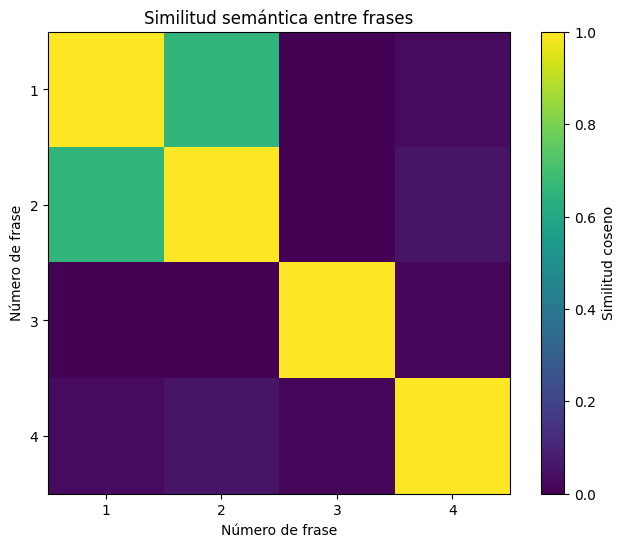

1. El gato duerme encima del sofá.
2. Un felino está descansando sobre el sillón.
3. Mañana lloverá en el norte.
4. La bolsa cerró con fuertes pérdidas.


In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(similitud, vmin=0, vmax=1)
plt.xticks(range(len(frases)), range(1, len(frases) + 1))
plt.yticks(range(len(frases)), range(1, len(frases) + 1))
plt.colorbar(label="Similitud coseno")
plt.title("Similitud semántica entre frases")
plt.xlabel("Número de frase")
plt.ylabel("Número de frase")
plt.show()

for i, frase in enumerate(frases, start=1):
    print(f"{i}. {frase}")

## 7. ¿Dónde se guardan los modelos?

Hugging Face mantiene una caché local. La ruta exacta puede consultarse así:


In [15]:
from huggingface_hub.constants import HF_HUB_CACHE
print(HF_HUB_CACHE)

/root/.cache/huggingface/hub


## 8. Uso sin conexión después de la descarga

Tras ejecutar al menos una vez las celdas que cargan cada modelo, se puede activar el modo sin conexión **antes de importar o cargar de nuevo los modelos**:

```python
import os
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
```

También se puede añadir `local_files_only=True` en llamadas como `from_pretrained(...)`.
